In [1]:
import torch

# Check if PyTorch recognizes the GPU
print(f"Is CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")


import torch
print(torch.__version__)

Is CUDA available: True
CUDA version: 12.1
GPU Name: NVIDIA GeForce RTX 4080 SUPER
2.2.2+cu121


# Berlin Training  (using domain adapted fusion with SAR)

In [1]:
MODEL_FLAGS="--attention_resolutions 32,16,8 --class_cond True --diffusion_steps 1000 --dropout 0.1 --image_size 64 --learn_sigma True --noise_schedule cosine --num_channels 192 --num_head_channels 64 --num_res_blocks 3 --resblock_updown True --use_new_attention_order True --use_fp16 True --use_scale_shift_norm True"
#python classifier_sample.py $MODEL_FLAGS --classifier_scale 1.0 --classifier_path models/64x64_classifier.pt --classifier_depth 4 --model_path models/64x64_diffusion.pt $SAMPLE_FLAGS

In [ ]:
%run train_Berlin_sar_pca_rgb.py --exp exp_set/Berlin_benchmark/datasetDDPM_sar.json $MODEL_FLAGS

Using seed: 21
> e:\unidiff\train_berlin_sar_pca_rgb.py(550)<module>()
    548         pdb.set_trace()
    549 
--> 550         if 'seed' in opts:
    551             suffix += f"_seed{opts['seed']}"
    552         else:



ipdb>  n


> e:\unidiff\train_berlin_sar_pca_rgb.py(551)<module>()
    549 
    550         if 'seed' in opts:
--> 551             suffix += f"_seed{opts['seed']}"
    552         else:
    553             suffix += "_seed0"   # fallback if missing



ipdb>  n


> e:\unidiff\train_berlin_sar_pca_rgb.py(555)<module>()
    553             suffix += "_seed0"   # fallback if missing
    554 
--> 555         opts['exp_dir'] = os.path.join(opts['exp_dir'], suffix)
    556 
    557 



ipdb>  suffix


'300_11_seed21'


In [ ]:
import itertools
import json
import os
import subprocess
from pathlib import Path

# ==== User config ====
BASE_JSON = "exp_set/Berlin_benchmark/datasetDDPM_pca.json"
TRAIN_PY = "train_Berlin_sar_pca_rgb.py"
PYTHON_BIN = "python"  # or "python3"

MODEL_FLAGS = [
    "--attention_resolutions", "32,16,8",
    "--class_cond", "True",
    "--diffusion_steps", "1000",
    "--dropout", "0.1",
    "--image_size", "64",
    "--learn_sigma", "True",
    "--noise_schedule", "cosine",
    "--num_channels", "192",
    "--num_head_channels", "64",
    "--num_res_blocks", "3",
    "--resblock_updown", "True",
    "--use_new_attention_order", "True",
    "--use_fp16", "True",
    "--use_scale_shift_norm", "True"
]

# Mapping index to name
idx2name = {0: "rgb", 1: "pca", 2: "sar"}

# ==== Load base config ====
with open(BASE_JSON, "r") as f:
    base_cfg = json.load(f)

EXP_DIR_BASE = base_cfg["exp_dir"].rstrip("/")

# ==== Build all combos ====
'''
COMBOS = [
    (0,), (1,), (2,),  # singles
    (0, 1), (0, 2), (1, 2),  # pairs
    (0, 1, 2)  # all
]
'''
COMBOS = [
    (1,)

]
# ==== Run experiments ====
for combo in COMBOS:
    # Convert indices to readable name
    name = "_".join(idx2name[i] for i in combo)
    exp_dir = f"{EXP_DIR_BASE}/{name}"
    print(f"\n=== Running combo {combo} -> {name} ===")

    # Prepare config for this run
    cfg = dict(base_cfg)
    cfg["use_modalities"] = list(combo)
    cfg["exp_dir"] = exp_dir

    # Save config to exp_dir/config.used.json
    Path(exp_dir).mkdir(parents=True, exist_ok=True)
    config_path = Path(exp_dir) / "config.used.json"
    with open(config_path, "w") as f:
        json.dump(cfg, f, indent=2)

    # Build and run command
    cmd = [PYTHON_BIN, TRAIN_PY, "--exp", str(config_path)] + MODEL_FLAGS
    print("+", " ".join(cmd))
    ret = subprocess.call(cmd)
    if ret != 0:
        print(f"Run failed for {name}")
        break

print("\nAll combos finished.")



=== Running combo (1,) -> pca ===
+ python train_Berlin_sar_pca_rgb.py --exp exp_result\Berlin_pca_full\M2000\no_mixup\pca\config.used.json --attention_resolutions 32,16,8 --class_cond True --diffusion_steps 1000 --dropout 0.1 --image_size 64 --learn_sigma True --noise_schedule cosine --num_channels 192 --num_head_channels 64 --num_res_blocks 3 --resblock_updown True --use_new_attention_order True --use_fp16 True --use_scale_shift_norm True


In [2]:
Start-Process python -ArgumentList 'run_all_1.py' -WindowStyle Hidden


SyntaxError: invalid syntax (4268110892.py, line 1)

# Augsburg Traing (using pre-trained)

In [1]:
MODEL_FLAGS="--attention_resolutions 32,16,8 --class_cond True --diffusion_steps 1000 --dropout 0.1 --image_size 64 --learn_sigma True --noise_schedule cosine --num_channels 192 --num_head_channels 64 --num_res_blocks 3 --resblock_updown True --use_new_attention_order True --use_fp16 True --use_scale_shift_norm True"
#python classifier_sample.py $MODEL_FLAGS --classifier_scale 1.0 --classifier_path models/64x64_classifier.pt --classifier_depth 4 --model_path models/64x64_diffusion.pt $SAMPLE_FLAGS

Seed:  0
Experiment folder: exp_result/Augsburg/pre_trained/dsm\100_10
Loading pretrained models...
Creating DDPM Feature Extractor...
Pretrained model is successfully loaded from checkpoints/ddpm/64x64_diffusion.pt
Taking first 150 samples...


100%|████████████████████████████████████████████████████████████████████████████████| 150/150 [00:08<00:00, 16.92it/s]


save the predcitons lables to exp_result/Augsburg/pre_trained/dsm\100_10\predictions
saving 0th file 
saving 100th file 
Save inference map toexp_result/Augsburg/pre_trained/dsm\100_10\visualizations\inference_map.jpg 
Per-Class Metrics:
Forest -   Recall: 0.7769, Precision: 0.9675,F1 Score: 0.8618, IoU: 0.7571
Residential Area -   Recall: 0.9242, Precision: 0.7235,F1 Score: 0.8117, IoU: 0.6830
Industrial Area -   Recall: 0.0742, Precision: 0.2913,F1 Score: 0.1182, IoU: 0.0628
Low Plants -   Recall: 0.8940, Precision: 0.9074,F1 Score: 0.9007, IoU: 0.8193
Allotment -   Recall: 0.3098, Precision: 0.2093,F1 Score: 0.2498, IoU: 0.1427
Commercial Area -   Recall: 0.0110, Precision: 0.2368,F1 Score: 0.0210, IoU: 0.0106
Water -   Recall: 0.1639, Precision: 0.6899,F1 Score: 0.2649, IoU: 0.1527
Overall accuracy: 0.8083
AA: 0.4506
Kappa Coefficient: 0.7126
Mean IoU: 0.3755
Mean F1 Score: 0.4611


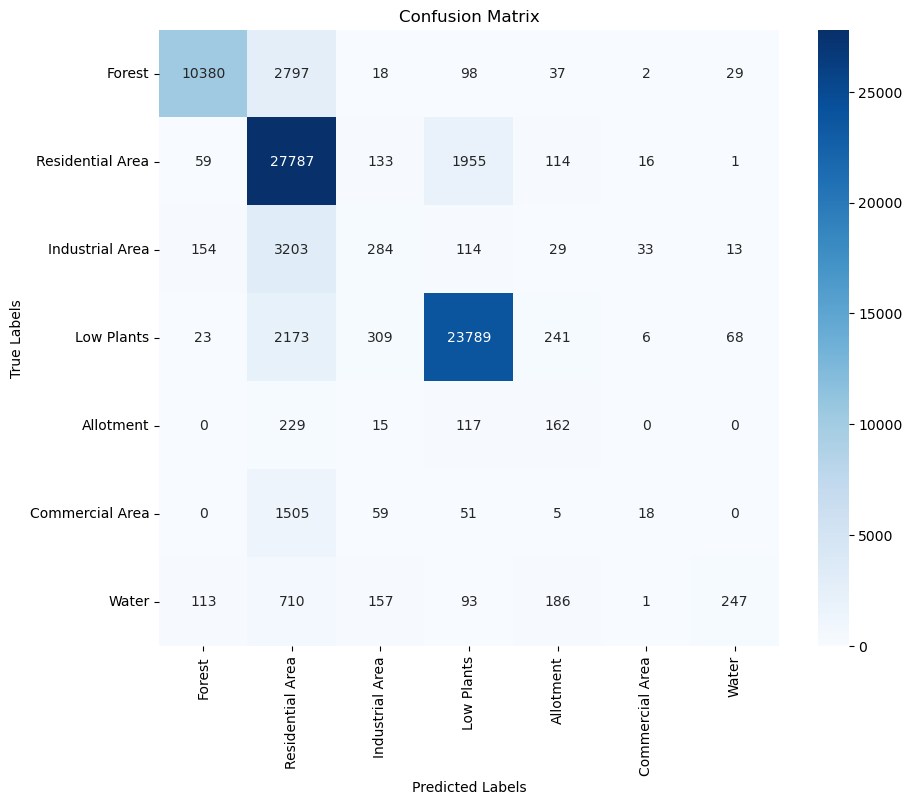

In [2]:
%run train_Berlin_sar_pca_rgb.py --exp exp_set/Augsburg_Benchmark/datasetDDPM.json $MODEL_FLAGS

# Augsburg Training (using domain adapted)

In [1]:
MODEL_FLAGS="--attention_resolutions 32,16,8 --class_cond True --diffusion_steps 1000 --dropout 0.1 --image_size 64 --learn_sigma True --noise_schedule cosine --num_channels 192 --num_head_channels 64 --num_res_blocks 3 --resblock_updown True --use_new_attention_order True --use_fp16 True --use_scale_shift_norm True"
#python classifier_sample.py $MODEL_FLAGS --classifier_scale 1.0 --classifier_path models/64x64_classifier.pt --classifier_depth 4 --model_path models/64x64_diffusion.pt $SAMPLE_FLAGS

> d:\one_pixel_two_features\train_augsburg.py(605)<module>()
    603     parser = argparse.ArgumentParser()
    604     pdb.set_trace()
--> 605     add_dict_to_argparser(parser, model_and_diffusion_defaults())
    606 
    607     parser.add_argument('--exp', type=str)



ipdb>  c


Seed:  0
Experiment folder: exp_result/Augsburg_Benchmark/augsburg_rgb_pca_patch_model2000\0_11
Creating DDPM Feature Extractor...
Pretrained model is successfully loaded from checkpoints/augsburg_rgb_pca_patch/model002000.pt
Preparing the training set for Augsburg...
Taking first 150 images...
> d:\one_pixel_two_features\train_augsburg.py(99)prepare_data()
     97     pdb.set_trace()
     98 
---> 99     for row, (img_pca,img_group,label) in enumerate(tqdm(dataset)):
    100 
    101         X_spatial_list = []



ipdb>  c


100%|████████████████████████████████████████████████████████████████████████████████| 150/150 [00:09<00:00, 16.16it/s]


...

ipdb>  c


100%|████████████████████████████████████████████████████████████████████████████████| 150/150 [00:13<00:00, 11.50it/s]


 ********* max_label 7 *** ignore_label 0 ***********
 *********************** Training dataloader length: 84 ***********************
 *********************** Training dataloader length: 2614 ***********************
Epoch: 0, Iteration: 20, Train Loss: 0.4089, Train Accuracy: 90.5134
Epoch: 0, Iteration: 40, Train Loss: 0.2472, Train Accuracy: 96.2054
Epoch: 0, Iteration: 60, Train Loss: 0.1683, Train Accuracy: 98.3259
Epoch: 0, Iteration: 80, Train Loss: 0.1103, Train Accuracy: 98.9955
Epoch: 1, Iteration: 100, Train Loss: 0.1156, Train Accuracy: 98.6607
Epoch: 1, Iteration: 120, Train Loss: 0.0514, Train Accuracy: 99.7396
Epoch: 1, Iteration: 140, Train Loss: 0.0607, Train Accuracy: 99.5536
Epoch: 1, Iteration: 160, Train Loss: 0.0720, Train Accuracy: 99.7768
Epoch: 2, Iteration: 180, Train Loss: 0.0681, Train Accuracy: 99.5908
Epoch: 2, Iteration: 200, Train Loss: 0.0252, Train Accuracy: 99.8140
Epoch: 2, Iteration: 220, Train Loss: 0.0122, Train Accuracy: 100.0000
Epoch: 2, Iterati

100%|████████████████████████████████████████████████████████████████████████████████| 150/150 [00:08<00:00, 17.98it/s]


save the predcitons lables to exp_result/Augsburg_Benchmark/augsburg_rgb_pca_patch_model2000\0_11\predictions
saving 0th file 
saving 100th file 
Save inference map toexp_result/Augsburg_Benchmark/augsburg_rgb_pca_patch_model2000\0_11\visualizations\inference_map.jpg 
Per-Class Metrics:
Forest -   Recall: 0.9335, Precision: 0.9596,F1 Score: 0.9464, IoU: 0.8982
Residential Area -   Recall: 0.9775, Precision: 0.9029,F1 Score: 0.9387, IoU: 0.8845
Industrial Area -   Recall: 0.4272, Precision: 0.6965,F1 Score: 0.5295, IoU: 0.3601
Low Plants -   Recall: 0.9634, Precision: 0.9335,F1 Score: 0.9482, IoU: 0.9016
Allotment -   Recall: 0.7801, Precision: 0.3228,F1 Score: 0.4566, IoU: 0.2959
Commercial Area -   Recall: 0.1007, Precision: 0.3011,F1 Score: 0.1510, IoU: 0.0816
Water -   Recall: 0.1685, Precision: 0.6978,F1 Score: 0.2715, IoU: 0.1571
Overall accuracy: 0.9023
AA: 0.6216
Kappa Coefficient: 0.8574
Mean IoU: 0.5113
Mean F1 Score: 0.6060


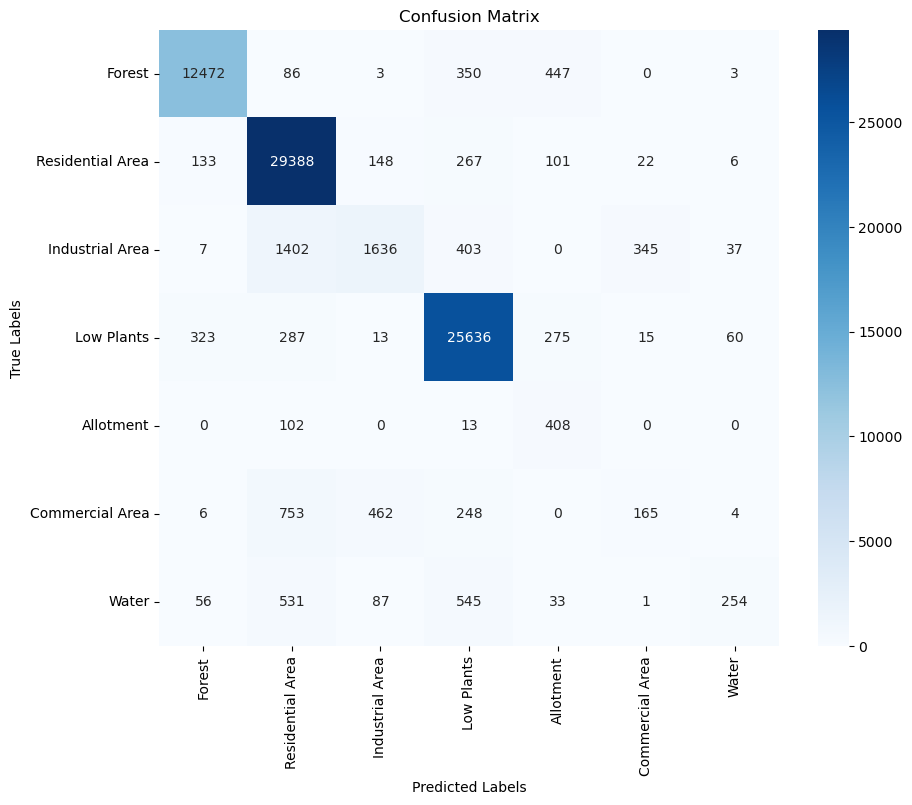

In [2]:
%run train_Augsburg.py --exp exp_set/Augsburg_Benchmark/datasetDDPM_ft.json $MODEL_FLAGS

# Continue Pretraining diffusion model( Augsburg)

In [1]:
MODEL_FLAGS="--attention_resolutions 32,16,8 --class_cond True --diffusion_steps 1000 --dropout 0.1 --image_size 64 --learn_sigma True --noise_schedule cosine --num_channels 192 --num_head_channels 64 --num_res_blocks 3 --resblock_updown True --use_new_attention_order True --use_fp16 True --use_scale_shift_norm True"
#python classifier_sample.py $MODEL_FLAGS --classifier_scale 1.0 --classifier_path models/64x64_classifier.pt --classifier_depth 4 --model_path models/64x64_diffusion.pt $SAMPLE_FLAGS
TRAIN_FLAGS="--lr 1e-4 --batch_size 32"

In [ ]:
%run image_train.py --data_dir datasets/Augsburg_benchmark/Augsburg_PCA_RGB $MODEL_FLAGS  $TRAIN_FLAGS 

Single GPU detected. Using local GPU without distributed setup.
Logging to C:\Users\hyz20\AppData\Local\Temp\openai-2025-09-03-21-38-09-938931
creating model and diffusion...
Loading pre-trained model from checkpoints/ddpm/64x64_diffusion.pt...
> e:\unidiff\image_train.py(58)main()
     56     logger.log(f"Loading pre-trained model from {pretrained_model_path}...")
     57     pdb.set_trace()
---> 58     model.load_state_dict(torch.load(pretrained_model_path, map_location=dist_util.dev()))
     59     """
     60     # adjusted with lora if use lora



ipdb>  c


creating data loader...
training...
loading data
----------------------------
| grad_norm     | 0.00181  |
| lg_loss_scale | 20       |
| loss          | 0.0874   |
| loss_q0       | 0.225    |
| loss_q1       | 0.0769   |
| loss_q2       | 0.0318   |
| loss_q3       | 0.00638  |
| mse           | 0.0856   |
| mse_q0        | 0.219    |
| mse_q1        | 0.0765   |
| mse_q2        | 0.0316   |
| mse_q3        | 0.00632  |
| param_norm    | 1.11e+03 |
| samples       | 32       |
| step          | 0        |
| vb            | 0.00172  |
| vb_q0         | 0.00565  |
| vb_q1         | 0.000398 |
| vb_q2         | 0.000157 |
| vb_q3         | 6.72e-05 |
----------------------------
saving model 0...
Model saved at: C:\Users\hyz20\AppData\Local\Temp\openai-2025-09-03-21-38-09-938931\model000000.pt
saving model 0.95...
Model saved at: C:\Users\hyz20\AppData\Local\Temp\openai-2025-09-03-21-38-09-938931\ema_0.95_000000.pt
----------------------------
| grad_norm     | 0.0017   |
| lg_loss_scal

# Continue pre-training diffusion model (with berlin RGB ,PCA and SAR)

In [ ]:
MODEL_FLAGS="--attention_resolutions 32,16,8 --class_cond True --diffusion_steps 1000 --dropout 0.1 --image_size 64 --learn_sigma True --noise_schedule cosine --num_channels 192 --num_head_channels 64 --num_res_blocks 3 --resblock_updown True --use_new_attention_order True --use_fp16 True --use_scale_shift_norm True"
#python classifier_sample.py $MODEL_FLAGS --classifier_scale 1.0 --classifier_path models/64x64_classifier.pt --classifier_depth 4 --model_path models/64x64_diffusion.pt $SAMPLE_FLAGS
TRAIN_FLAGS="--lr 1e-4 --batch_size 32"
%run image_train.py --data_dir datasets/Berlin_benchmark/rgb_pca_patches $MODEL_FLAGS  $TRAIN_FLAGS

Single GPU detected. Using local GPU without distributed setup.
Logging to C:\Users\hyz20\AppData\Local\Temp\openai-2025-08-27-12-16-14-493224
creating model and diffusion...
Loading pre-trained model from checkpoints/ddpm/64x64_diffusion.pt...
> e:\unidiff\image_train.py(58)main()
     56     logger.log(f"Loading pre-trained model from {pretrained_model_path}...")
     57     pdb.set_trace()
---> 58     model.load_state_dict(torch.load(pretrained_model_path, map_location=dist_util.dev()))
     59     """
     60     # adjusted with lora if use lora



ipdb>  c


creating data loader...
training...
loading data
----------------------------
| grad_norm     | 0.00456  |
| lg_loss_scale | 20       |
| loss          | 0.078    |
| loss_q0       | 0.201    |
| loss_q1       | 0.0488   |
| loss_q2       | 0.0131   |
| loss_q3       | 0.00253  |
| mse           | 0.0653   |
| mse_q0        | 0.161    |
| mse_q1        | 0.0486   |
| mse_q2        | 0.013    |
| mse_q3        | 0.0025   |
| param_norm    | 1.11e+03 |
| samples       | 32       |
| step          | 0        |
| vb            | 0.0127   |
| vb_q0         | 0.0403   |
| vb_q1         | 0.000262 |
| vb_q2         | 6.52e-05 |
| vb_q3         | 2.81e-05 |
----------------------------
saving model 0...
Model saved at: C:\Users\hyz20\AppData\Local\Temp\openai-2025-08-27-12-16-14-493224\model000000.pt
saving model 0.95...
Model saved at: C:\Users\hyz20\AppData\Local\Temp\openai-2025-08-27-12-16-14-493224\ema_0.95_000000.pt
----------------------------
| grad_norm     | 0.00215  |
| lg_loss_scal

# Sampling Augsburg from Finetuned Model  
- Set the domain adpated model path in `guided_diffusion/scripts/image_sample.py`  
- Configure the sampling class  
- Save sampled images in the `sample_images` folder  


## set  model path in image_sample.py

In [1]:
MODEL_FLAGS="--attention_resolutions 32,16,8 --class_cond True --diffusion_steps 1000 --dropout 0.1 --image_size 64 --learn_sigma True --noise_schedule cosine --num_channels 192 --num_head_channels 64 --num_res_blocks 3 --resblock_updown True --use_new_attention_order True --use_fp16 True --use_scale_shift_norm True"
SAMPLE_FLAGS="--batch_size 64 --num_samples 64 --timestep_respacing 1000"

In [ ]:
%run  guided_diffusion/scripts/image_sample.py --model_path checkpoints/ddpm/64x64_diffusion.pt $MODEL_FLAGS $SAMPLE_FLAGS

> e:\unidiff\guided_diffusion\scripts\image_sample.py(54)main()
     52     args = create_argparser().parse_args()
     53     pdb.set_trace()
---> 54     dist_util.setup_dist()
     55     logger.configure()
     56 



ipdb>  c


Single GPU detected. Using local GPU without distributed setup.
Logging to C:\Users\hyz20\AppData\Local\Temp\openai-2025-08-01-17-25-29-428677
creating model and diffusion...
> e:\unidiff\guided_diffusion\scripts\image_sample.py(76)main()
     74     pdb.set_trace()
     75 
---> 76     state_dict = th.load(pretrained_model_path, map_location='cpu')
     77 
     78 



ipdb>  c


Loading pre-trained model from checkpoints/berlin_pca_noise150/mixed_model.pth...
sampling...
Images saved to sample_images/berlin_pca_noise150_model2000mixed
> e:\unidiff\guided_diffusion\scripts\image_sample.py(115)main()
    113         pdb.set_trace()
    114 
--> 115         gathered_samples = [th.zeros_like(sample) for _ in range(dist.get_world_size())]
    116         dist.all_gather(gathered_samples, sample)  # gather not supported with NCCL
    117         all_images.extend([sample.cpu().numpy() for sample in gathered_samples])



# Domain adpated  model Augsburg bpd evaluation

In [3]:
MODEL_FLAGS="--attention_resolutions 32,16,8 --class_cond True --diffusion_steps 1000 --dropout 0.1 --image_size 64 --learn_sigma True --noise_schedule cosine --num_channels 192 --num_head_channels 64 --num_res_blocks 3 --resblock_updown True --use_new_attention_order True --use_fp16 False --use_scale_shift_norm True"
SAMPLE_FLAGS="--batch_size 32 --num_samples 128 --timestep_respacing 1000"

In [4]:
%run  guided_diffusion/scripts/image_nll.py --data_dir datasets/Augsburg_benchmark/Augsburg_PCA $MODEL_FLAGS $SAMPLE_FLAGS

Logging to exp_result/augsburg_bpd_patch/augsburg_0326_2021
Single GPU detected. Using local GPU without distributed setup.
creating model and diffusion...
Loading pre-trained model from checkpoints/augsburg_rgb_pca_patch/model000500.pt...
creating data loader...
evaluating...
Number of samples: 128
Data directory: datasets/Augsburg_benchmark/Augsburg_PCA
loading data
done 32 samples: bpd=5.563464164733887
done 64 samples: bpd=5.5182178020477295
done 96 samples: bpd=5.702999432881673
done 128 samples: bpd=5.814610600471497
saving vb terms to exp_result/augsburg_bpd_patch/augsburg_0326_2021\vb_terms.npz
saving mse terms to exp_result/augsburg_bpd_patch/augsburg_0326_2021\mse_terms.npz
saving xstart_mse terms to exp_result/augsburg_bpd_patch/augsburg_0326_2021\xstart_mse_terms.npz
evaluation complete


# Domain adpated model Berlin bpd evalutaion 

In [1]:
MODEL_FLAGS="--attention_resolutions 32,16,8 --class_cond True --diffusion_steps 1000 --dropout 0.1 --image_size 64 --learn_sigma True --noise_schedule cosine --num_channels 192 --num_head_channels 64 --num_res_blocks 3 --resblock_updown True --use_new_attention_order True --use_fp16 False --use_scale_shift_norm True"
SAMPLE_FLAGS="--batch_size 32 --num_samples 128 --timestep_respacing 1000"

In [2]:
%run  guided_diffusion/scripts/image_nll.py --data_dir datasets/Berlin_benchmark/Berlin_PCA $MODEL_FLAGS $SAMPLE_FLAGS

Logging to exp_result/Berlin_bpd_patch/berlin_0329_2335
Single GPU detected. Using local GPU without distributed setup.
creating model and diffusion...
Loading pre-trained model from checkpoints/berlin_rgb_pca_patch/model000500.pt...
creating data loader...
evaluating...
Number of samples: 128
Data directory: datasets/Berlin_benchmark/Berlin_PCA
loading data
done 32 samples: bpd=2.4107422828674316
done 64 samples: bpd=2.369827628135681
done 96 samples: bpd=2.373046080271403
done 128 samples: bpd=2.389772891998291
saving vb terms to exp_result/Berlin_bpd_patch/berlin_0329_2335\vb_terms.npz
saving mse terms to exp_result/Berlin_bpd_patch/berlin_0329_2335\mse_terms.npz
saving xstart_mse terms to exp_result/Berlin_bpd_patch/berlin_0329_2335\xstart_mse_terms.npz
evaluation complete
